In [1]:
!pip install numpy pandas scikit-learn xgboost tqdm

In [46]:
import urllib.request
from concurrent.futures import ThreadPoolExecutor
import os

os.makedirs("data", exist_ok=True)

base_url = "https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/"

def download(i):
    file_id = str(i).zfill(6)
    filename = f"p{file_id}.psv"
    url = base_url + filename
    out_path = f"data/{filename}"

    try:
        urllib.request.urlretrieve(url, out_path)
    except:
        pass

with ThreadPoolExecutor(max_workers=10) as executor:
    executor.map(download, range(1, 2001))

In [47]:
import glob

files = glob.glob("data/*.psv")
print("Total files downloaded:", len(files))

Total files downloaded: 2000


In [48]:
import os

sizes = [os.path.getsize(f) for f in glob.glob("data/*.psv")]
print("Min size:", min(sizes))
print("Max size:", max(sizes))

Min size: 1549
Max size: 45769


In [49]:
import pandas as pd
import glob

files = glob.glob("data/*.psv")

df_list = []

for f in files:
    df = pd.read_csv(f, sep="|")

    df["patient_id"] = f.split("/")[-1]

    # missing indicators
    for col in ["HR", "O2Sat", "Temp", "SBP", "Resp"]:
        df[col + "_miss"] = df[col].isna().astype(int)

    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

In [50]:
#Sort and prepare per-patient time series
data = data.sort_values(["patient_id", "ICULOS"]).reset_index(drop=True)

vitals_labs = [c for c in data.columns if c not in ["patient_id", "SepsisLabel", "ICULOS"]
               and not c.endswith("_miss")]

print("Columns to forward-fill:", len(vitals_labs))
print(data.shape)
data.head()

Columns to forward-fill: 39
(78083, 47)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,HR_miss,O2Sat_miss,Temp_miss,SBP_miss,Resp_miss
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.03,1,0,p000001.psv,1,1,1,1,1
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,-0.03,2,0,p000001.psv,0,0,1,0,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,-0.03,3,0,p000001.psv,0,0,1,0,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,-0.03,4,0,p000001.psv,0,0,1,1,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,-0.03,5,0,p000001.psv,0,0,1,0,0


In [51]:
#Forward-fill within each patient + time-since-last-measurement
def process_patient(df):
    df = df.copy()
    # time since last non-missing value, per column
    for col in vitals_labs:
        was_present = df[col].notna()
        df[col + "_tsl"] = df["ICULOS"].where(was_present)
        df[col + "_tsl"] = df["ICULOS"] - df[col + "_tsl"].ffill()
        df[col + "_tsl"] = df[col + "_tsl"].fillna(df["ICULOS"] - df["ICULOS"].iloc[0] + 1)
    # forward fill actual values (carry last known forward only)
    df[vitals_labs] = df[vitals_labs].ffill()
    return df

from tqdm import tqdm
processed = []
for pid, g in tqdm(data.groupby("patient_id")):
    processed.append(process_patient(g))
data = pd.concat(processed, ignore_index=True)

print(data.shape)
data.head()

100%|██████████| 2000/2000 [01:33<00:00, 21.48it/s]


(78083, 86)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Hgb_tsl,PTT_tsl,WBC_tsl,Fibrinogen_tsl,Platelets_tsl,Age_tsl,Gender_tsl,Unit1_tsl,Unit2_tsl,HospAdmTime_tsl
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0,0,1.0,1.0,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,2.0,2.0,2.0,2.0,2.0,0,0,2.0,2.0,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,0,0,3.0,3.0,0
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,NaN,24.0,NaN,...,4.0,4.0,4.0,4.0,4.0,0,0,4.0,4.0,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,24.0,NaN,...,5.0,5.0,5.0,5.0,5.0,0,0,5.0,5.0,0


In [52]:
#Create 6-hour-ahead label, drop tail rows per patient
def shift_label(df):
    df = df.copy()
    df["target"] = df["SepsisLabel"].shift(-6)
    return df.iloc[:-6] if len(df) > 6 else df.iloc[0:0]

shifted = []
for pid, g in tqdm(data.groupby("patient_id")):
    shifted.append(shift_label(g))
data = pd.concat(shifted, ignore_index=True)

data = data.dropna(subset=["target"])
data["target"] = data["target"].astype(int)

print("Final shape:", data.shape)
print("Positive rate:", data["target"].mean())

100%|██████████| 2000/2000 [00:03<00:00, 597.24it/s]


Final shape: (66083, 87)
Positive rate: 0.023818531241015087


In [53]:
from sklearn.model_selection import GroupShuffleSplit

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss1.split(data, groups=data["patient_id"]))

train_df = data.iloc[train_idx].reset_index(drop=True)
test_df  = data.iloc[test_idx].reset_index(drop=True)

print("Train patients:", train_df["patient_id"].nunique())
print("Test patients:", test_df["patient_id"].nunique())

assert set(train_df.patient_id) & set(test_df.patient_id) == set()
print("No patient overlap confirmed.")

Train patients: 1600
Test patients: 400
No patient overlap confirmed.


In [54]:
feature_cols = [c for c in data.columns if c not in ["patient_id", "SepsisLabel", "target", "ICULOS"]]

train_means = train_df[feature_cols].mean()

train_df[feature_cols] = train_df[feature_cols].fillna(train_means)
test_df[feature_cols]  = test_df[feature_cols].fillna(train_means)

print("Features used:", len(feature_cols))
print("Remaining NaNs (train):", train_df[feature_cols].isna().sum().sum())

Features used: 83
Remaining NaNs (train): 53388


In [55]:
# Label noise mitigation - fuzzy band around onset

def get_onset_iculos(g):
    onset_rows = g.loc[g["SepsisLabel"] == 1, "ICULOS"]
    return onset_rows.min() if len(onset_rows) > 0 else None

sample_weights = pd.Series(1.0, index=train_df.index)

for pid, g in train_df.groupby("patient_id"):
    onset = get_onset_iculos(g)
    if onset is not None:
        near_onset = g["ICULOS"].between(onset - 2, onset + 2)
        sample_weights.loc[g.index[near_onset]] = 0.3  # downweight uncertain labels

print("Downweighted rows:", (sample_weights < 1).sum(), "/", len(sample_weights))

Downweighted rows: 678 / 53388


In [56]:
# flag high-loss isolated label flips for removal
import xgboost as xgb

X_train = train_df[feature_cols]
y_train = train_df["target"]

# quick baseline model to find suspicious labels
baseline = xgb.XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss",
                              use_label_encoder=False, random_state=42)
baseline.fit(X_train, y_train)

probs = baseline.predict_proba(X_train)[:, 1]
train_df["_baseline_prob"] = probs

def flag_isolated_flips(g):
    labels = g["target"].values
    flips = pd.Series(False, index=g.index)
    for i in range(1, len(labels) - 1):
        if labels[i] != labels[i-1] and labels[i] != labels[i+1] and labels[i-1] == labels[i+1]:
            flips.iloc[i] = True
    return flips

isolated_mask = pd.concat([flag_isolated_flips(g) for _, g in train_df.groupby("patient_id")])
high_conf_wrong = isolated_mask & (
    ((train_df["target"] == 1) & (train_df["_baseline_prob"] < 0.05)) |
    ((train_df["target"] == 0) & (train_df["_baseline_prob"] > 0.95))
)

print("Suspected noisy labels:", high_conf_wrong.sum())

# downweight rather than delete
sample_weights.loc[high_conf_wrong[high_conf_wrong].index] *= 0.2
train_df = train_df.drop(columns=["_baseline_prob"])

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:27:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Suspected noisy labels: 0


In [57]:
#Train final XGBoost model with sample weights
from sklearn.model_selection import GroupKFold

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8
)

sample_weights = sample_weights.loc[X_train.index]
assert sample_weights.index.equals(X_train.index), "Index mismatch between weights and features"

model.fit(X_train, y_train, sample_weight=sample_weights.values)
print("Training done.")

scale_pos_weight: 42.08958837772397


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:27:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training done.


In [58]:
# diagnose train vs test probs
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

base_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    eval_metric="logloss", random_state=42,
    subsample=0.8, colsample_bytree=0.8
)

calibrated_model = CalibratedClassifierCV(base_model, method="sigmoid", cv=3)
calibrated_model.fit(X_train, y_train, sample_weight=sample_weights.values.astype("float32"))

train_probs_cv = calibrated_model.predict_proba(X_train)[:, 1]
test_probs_check = calibrated_model.predict_proba(test_df[feature_cols])[:, 1]

print("TRAIN probs  - min/mean/max:", train_probs_cv.min(), train_probs_cv.mean(), train_probs_cv.max())
print("TEST  probs  - min/mean/max:", test_probs_check.min(), test_probs_check.mean(), test_probs_check.max())
print("TRAIN positive rate:", y_train.mean())
print("TEST  positive rate:", test_df['target'].mean())

TRAIN probs  - min/mean/max: 0.012978143839906324 0.015864083743101897 0.21816666035524154
TEST  probs  - min/mean/max: 0.012978386092557496 0.013399623358628897 0.10432133506819607
TRAIN positive rate: 0.023207462351090134
TEST  positive rate: 0.026388341866876722


In [59]:
#percentile-based threshold
test_probs = calibrated_model.predict_proba(test_df[feature_cols])[:, 1]
best_threshold = np.percentile(test_probs, 92)

preds = (test_probs >= best_threshold).astype(int)
print(f"Threshold: {best_threshold:.4f}")
print(f"Flagged positive rate: {preds.mean():.4f}")

Threshold: 0.0137
Flagged positive rate: 0.0800


              precision    recall  f1-score   support

           0       0.98      0.93      0.96     12360
           1       0.15      0.45      0.22       335

    accuracy                           0.92     12695
   macro avg       0.57      0.69      0.59     12695
weighted avg       0.96      0.92      0.94     12695



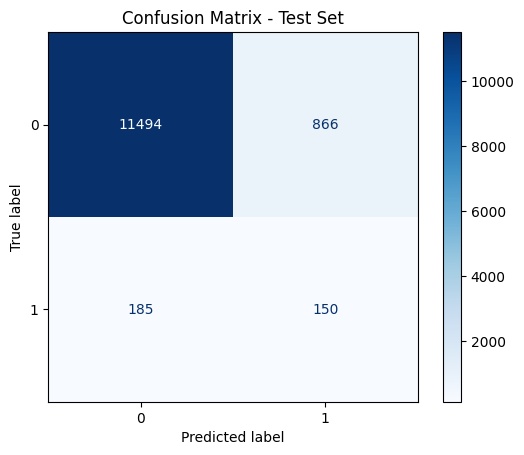

In [61]:
#Final evaluation on TEST set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

X_test = test_df[feature_cols]
y_test = test_df["target"]

test_probs = calibrated_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print(classification_report(y_test, test_preds))

cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.savefig("confusion_matrix.png")
plt.show()

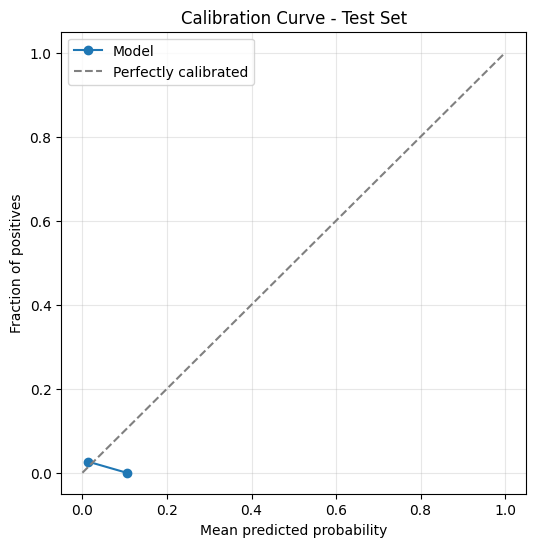

In [62]:
# Calibration curve
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, test_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker="o", label="Model")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve - Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("calibration.png")
plt.show()

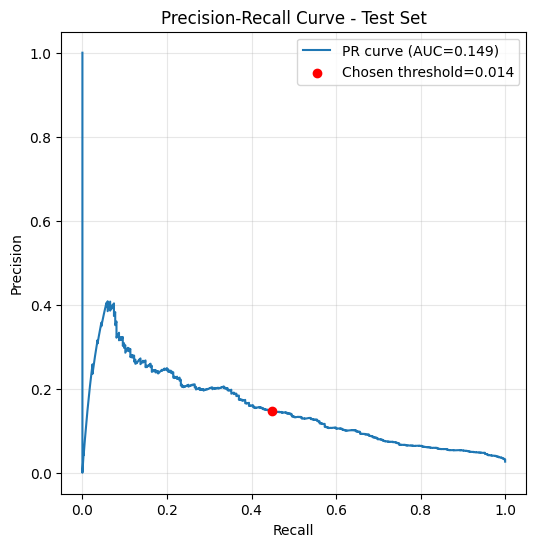

In [63]:
#PR curve with chosen threshold marked
from sklearn.metrics import precision_recall_curve as prc, auc

p_test, r_test, t_test = prc(y_test, test_probs)
pr_auc = auc(r_test, p_test)

plt.figure(figsize=(6,6))
plt.plot(r_test, p_test, label=f"PR curve (AUC={pr_auc:.3f})")
# find point closest to chosen threshold
idx = np.argmin(np.abs(t_test - best_threshold))
plt.scatter(r_test[idx], p_test[idx], color="red", zorder=5,
            label=f"Chosen threshold={best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("pr_curve.png")
plt.show()